## Analysis of spatial factors corresponding to myoepithelial subpopulations

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
import os
import sys

import warnings
warnings.filterwarnings("ignore")

### Load results

In [2]:
res_path = "/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/tutorials/new_examples/human_breast_cancer_xenium"
adata = sc.read_h5ad(res_path + "/adata_inspire.h5ad")
basis_df = pd.read_csv(res_path + "/basis_df_inspire.csv", index_col=0)
adata.obsm["factors"] = np.array(adata.obs[["Proportion of spatial factor "+str(j+1) for j in range(50)]].values)

### Visualization of gene signatures

In [3]:
topic_id = 30

topic_profile = np.array(basis_df.iloc[topic_id,:].values)
order = np.argsort(-topic_profile)
print(basis_df.columns[order])

potential_marker = list(basis_df.columns[order[:50]])
marker_ours = []
for i in range(len(potential_marker)):
    id_1 = np.argsort(-basis_df[potential_marker[i]])[0]
    id_2 = np.argsort(-basis_df[potential_marker[i]])[1]
    val_1 = basis_df[potential_marker[i]][id_1]
    val_2 = basis_df[potential_marker[i]][id_2]
    if (id_1 == topic_id) & (val_1 >= (val_2*1.5)):
        marker_ours.append(potential_marker[i])
print(marker_ours)

Index(['KRT15', 'SFRP1', 'KRT23', 'PTN', 'TACSTD2', 'KRT7', 'PIGR', 'ALDH1A3',
       'OPRPN', 'KIT',
       ...
       'CD93', 'SFRP4', 'PTPRC', 'ADH1B', 'LYZ', 'IL7R', 'VWF', 'CXCL12',
       'PECAM1', 'POSTN'],
      dtype='object', length=313)
['KRT15', 'SFRP1', 'KRT23', 'PIGR', 'OPRPN', 'ELF5', 'S100A8']


In [4]:
topic_id = 34

topic_profile = np.array(basis_df.iloc[topic_id,:].values)
order = np.argsort(-topic_profile)
print(basis_df.columns[order])

potential_marker = list(basis_df.columns[order[:50]])
marker_ours = []
for i in range(len(potential_marker)):
    id_1 = np.argsort(-basis_df[potential_marker[i]])[0]
    id_2 = np.argsort(-basis_df[potential_marker[i]])[1]
    val_1 = basis_df[potential_marker[i]][id_1]
    val_2 = basis_df[potential_marker[i]][id_2]
    if (id_1 == topic_id) & (val_1 >= (val_2*1.5)):
        marker_ours.append(potential_marker[i])
print(marker_ours)

Index(['KRT6B', 'KRT5', 'KRT16', 'KRT14', 'DSP', 'SERPINA3', 'C5orf46', 'DSC2',
       'MYLK', 'EGFR',
       ...
       'CD8A', 'CD93', 'PTPRC', 'SFRP4', 'LYZ', 'CXCL12', 'ADH1B', 'VWF',
       'IL7R', 'PECAM1'],
      dtype='object', length=313)
['KRT6B', 'KRT16', 'C5orf46', 'DSC2', 'FOXC2', 'CLCA2']


In [5]:
topic_id = 37

topic_profile = np.array(basis_df.iloc[topic_id,:].values)
order = np.argsort(-topic_profile)
print(basis_df.columns[order])

potential_marker = list(basis_df.columns[order[:50]])
marker_ours = []
for i in range(len(potential_marker)):
    id_1 = np.argsort(-basis_df[potential_marker[i]])[0]
    id_2 = np.argsort(-basis_df[potential_marker[i]])[1]
    val_1 = basis_df[potential_marker[i]][id_1]
    val_2 = basis_df[potential_marker[i]][id_2]
    if (id_1 == topic_id) & (val_1 >= (val_2*1.5)):
        marker_ours.append(potential_marker[i])
print(marker_ours)

Index(['MYLK', 'KRT14', 'MYH11', 'KRT5', 'OXTR', 'DST', 'ACTA2', 'ACTG2',
       'SFRP1', 'PTN',
       ...
       'CD3E', 'CXCR4', 'PTPRC', 'CXCL12', 'VWF', 'SFRP4', 'ADH1B', 'LYZ',
       'IL7R', 'PECAM1'],
      dtype='object', length=313)
['KRT14', 'OXTR', 'DST', 'ACTG2', 'PGR']


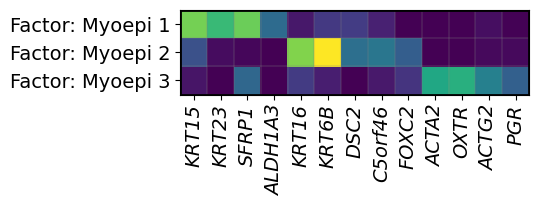

In [6]:
gene_list = ['KRT15', 'KRT23', 'SFRP1', 'ALDH1A3'] + ['KRT16', 'KRT6B', 'DSC2', 'C5orf46', 'FOXC2'] + ['ACTA2', 'OXTR','ACTG2', 'PGR']


n_factors = 3
gene_set = gene_list
profile = basis_df.iloc[[30,34,37], :]
profile = profile[gene_set]
factor_names = ["Factor: Myoepi 1", "Factor: Myoepi 2", "Factor: Myoepi 3"]

f = plt.figure(figsize=(4.5,1.1))
ax = f.add_subplot(111)
# ax.set_ylabel('Factor', fontsize=14)
im = ax.imshow(profile, cmap='viridis', interpolation='nearest', aspect='auto')
plt.yticks(np.arange(n_factors), factor_names, rotation=0, fontsize=14)
plt.xticks(np.arange(len(gene_set)), gene_set, rotation=90, fontsize=14, style="italic")
# plt.title("Gene signature of factors", fontsize=15)
plt.vlines(x=np.arange(len(gene_set))-0.5, ymin=-0.5, ymax=n_factors-0.5, color="gray", linewidth=1.5, alpha=0.2)
plt.hlines(y=np.arange(n_factors)-0.5, xmin=-0.5, xmax=len(gene_set)-0.5, color="gray", linewidth=1.5, alpha=0.2)
plt.vlines(x=-0.5, ymin=-0.5, ymax=n_factors-0.5, color="k", linewidth=2, alpha=1)
plt.vlines(x=len(gene_set)-0.5, ymin=-0.5, ymax=n_factors-0.5, color="k", linewidth=2, alpha=1)
plt.hlines(y=-0.5, xmin=-0.5, xmax=len(gene_set)-0.5, color="k", linewidth=2, alpha=1)
plt.hlines(y=n_factors-0.5, xmin=-0.5, xmax=len(gene_set)-0.5, color="k", linewidth=2, alpha=1)

plt.show()

### Gene expression pattern among myoepithelial factor-related cells

In [7]:
adata.obs["factor"] = "unknown"

factor_prop = adata.obs["Proportion of spatial factor 31"].values
factor_prop_max = np.max(adata.obsm["factors"], axis=1)
adata.obs["factor"][factor_prop >= factor_prop_max] = "Myoepi 1"

factor_prop = adata.obs["Proportion of spatial factor 35"].values
factor_prop_max = np.max(adata.obsm["factors"], axis=1)
adata.obs["factor"][factor_prop >= factor_prop_max] = "Myoepi 2"

factor_prop = adata.obs["Proportion of spatial factor 38"].values
factor_prop_max = np.max(adata.obsm["factors"], axis=1)
adata.obs["factor"][factor_prop >= factor_prop_max] = "Myoepi 3"

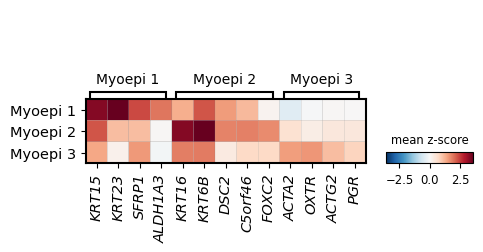

In [8]:
adata_raw = sc.read_h5ad("/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/tumor_microenvironment/Xenium_BC/adata_raw_umap.h5ad")
adata_raw.obs["Myoepi"] = adata.obs["factor"].values.astype(str)
adata_1 = adata_raw[adata_raw.obs["Myoepi"] == "Myoepi 1", :].copy()
adata_2 = adata_raw[adata_raw.obs["Myoepi"] == "Myoepi 2", :].copy()
adata_3 = adata_raw[adata_raw.obs["Myoepi"] == "Myoepi 3", :].copy()
adata_myoepi = ad.concat([adata_1, adata_2, adata_3])

marker_genes_dict = {"Myoepi 1": ['KRT15', 'KRT23', 'SFRP1', 'ALDH1A3'],
                     "Myoepi 2": ['KRT16', 'KRT6B', 'DSC2', 'C5orf46', 'FOXC2'],
                     "Myoepi 3": ['ACTA2', 'OXTR','ACTG2', 'PGR']}

fig, ax = plt.subplots(figsize=(5,2))
mt = sc.pl.matrixplot(
    adata_myoepi,
    marker_genes_dict,
    "Myoepi",
    dendrogram=False,
    colorbar_title="mean z-score",
    # layer="scaled",
    cmap="RdBu_r",
    # cmap="Reds",
    vmax=3.6,
    vmin=-3.6,
    # vmin=0.
    var_group_rotation=0,
    ax=ax,
    show=False
)
ax_main = mt['mainplot_ax']
for l in ax_main.get_xticklabels():
    l.set_style('italic')
    l.set_fontsize(10.5)
for l in ax_main.get_yticklabels():
    l.set_fontsize(10.5)

plt.show()

### Correlation analysis of spatial factors and their associated gene expression profiles

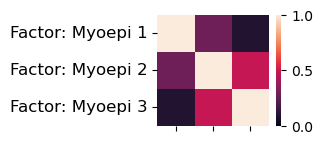

In [9]:
factor_myoepi = np.array(adata.obs[["Proportion of spatial factor 31", "Proportion of spatial factor 35", "Proportion of spatial factor 38"]].values)
corr_factor = np.corrcoef(factor_myoepi.T)

import seaborn as sns

plt.figure(figsize = (2*0.9,1.6*0.9))
sns.heatmap(corr_factor, vmin=0., vmax=1.)
plt.yticks(ticks=[0.5,1.5,2.5], labels=["Factor: Myoepi 1", "Factor: Myoepi 2", "Factor: Myoepi 3"], rotation=0, fontsize=12)
plt.xticks(ticks=[0.5,1.5,2.5], labels=["", "", ""])

plt.show()

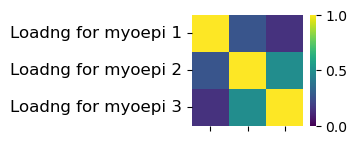

In [10]:
import seaborn as sns
corr_loading = basis_df.iloc[[30,34,37], :].T.corr()

import seaborn as sns

plt.figure(figsize = (2*0.9,1.6*0.9))
sns.heatmap(corr_loading, vmin=0., vmax=1., cmap="viridis")
plt.yticks(ticks=[0.5,1.5,2.5], labels=["Loadng for myoepi 1", "Loadng for myoepi 2", "Loadng for myoepi 3"], rotation=0, fontsize=12)
plt.xticks(ticks=[0.5,1.5,2.5], labels=["", "", ""])

plt.show()

### Construction of the spatial map for myoepithelial factor-related cells

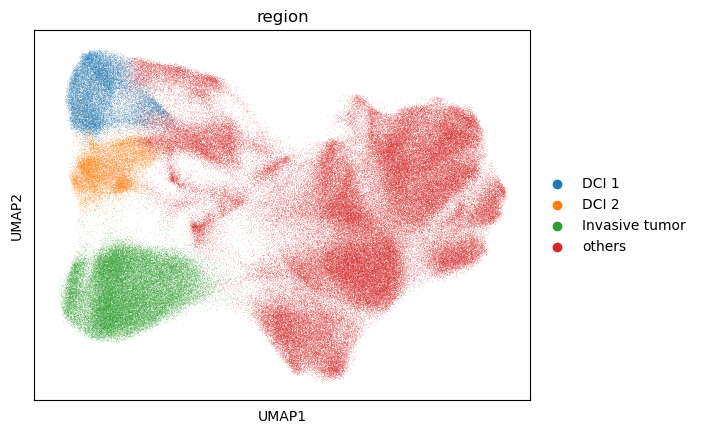

In [11]:
adata = sc.read_h5ad(res_path + "/adata_inspire_with_louvain.h5ad")
adata.obsm["factors"] = np.array(adata.obs[["Proportion of spatial factor "+str(j+1) for j in range(50)]].values)

adata.obs["region"] = "others"
adata.obs["region"][adata.obs["louvain"].values.astype(str) == "2"] = "DCI 1"
adata.obs["region"][adata.obs["louvain"].values.astype(str) == "8"] = "DCI 2"
adata.obs["region"][adata.obs["louvain"].values.astype(str) == "0"] = "Invasive tumor"

sc.pl.umap(adata, color="region")

In [12]:
adata.obs["factor"] = "unknown"

factor_prop = adata.obs["Proportion of spatial factor 31"].values
factor_prop_max = np.max(adata.obsm["factors"], axis=1)
adata.obs["factor"][factor_prop >= factor_prop_max] = "Myoepi 1"

factor_prop = adata.obs["Proportion of spatial factor 35"].values
factor_prop_max = np.max(adata.obsm["factors"], axis=1)
adata.obs["factor"][factor_prop >= factor_prop_max] = "Myoepi 2"

factor_prop = adata.obs["Proportion of spatial factor 38"].values
factor_prop_max = np.max(adata.obsm["factors"], axis=1)
adata.obs["factor"][factor_prop >= factor_prop_max] = "Myoepi 3"

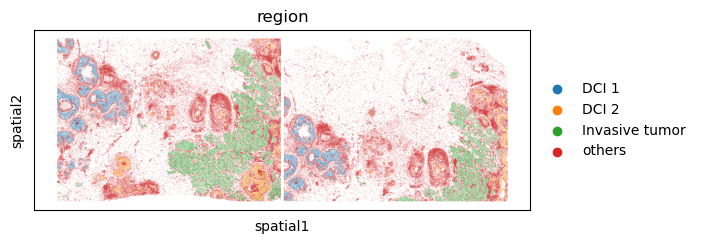

In [13]:
sc.pl.spatial(adata, color="region", spot_size=10.)

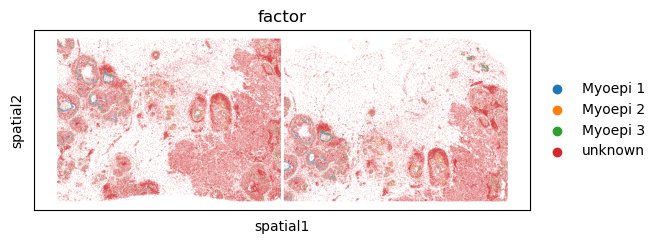

In [14]:
sc.pl.spatial(adata, color="factor", spot_size=10.)

### Spatial colocalization analysis between myoepithelial factor-related cells and distinct tumor subtypes

In [15]:
### calculate co-localize
adata_rep1 = adata[adata.obs["slice_label"].values.astype(str) == "0", :].copy()
adata_rep2 = adata[adata.obs["slice_label"].values.astype(str) == "1", :].copy()

loc_rep1 = adata_rep1.obsm["spatial"]
loc_rep2 = adata_rep2.obsm["spatial"]

In [16]:
coloc_val = np.zeros((3,3)) #factor by tumor type

k_nn = 50
adata_tmp = adata_rep1.copy()
loc_tmp = loc_rep1.copy()


tumor_type = "DCI 1"
cell_type = "Myoepi 1"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[0,0] = count / len(idx_tumor)


tumor_type = "DCI 2"
cell_type = "Myoepi 1"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[0,1] = count / len(idx_tumor)


tumor_type = "Invasive tumor"
cell_type = "Myoepi 1"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[0,2] = count / len(idx_tumor)



tumor_type = "DCI 1"
cell_type = "Myoepi 2"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[1,0] = count / len(idx_tumor)


tumor_type = "DCI 2"
cell_type = "Myoepi 2"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[1,1] = count / len(idx_tumor)


tumor_type = "Invasive tumor"
cell_type = "Myoepi 2"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[1,2] = count / len(idx_tumor)


tumor_type = "DCI 1"
cell_type = "Myoepi 3"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[2,0] = count / len(idx_tumor)



tumor_type = "DCI 2"
cell_type = "Myoepi 3"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[2,1] = count / len(idx_tumor)


tumor_type = "Invasive tumor"
cell_type = "Myoepi 3"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[2,2] = count / len(idx_tumor)

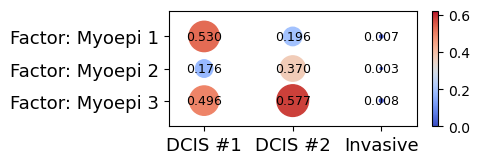

In [17]:
f, ax = plt.subplots(figsize=(4, 1.5))
n_topic = 3

for j in range(3):
    y = coloc_val[j, :]
    plt.scatter(np.arange(n_topic), (np.ones(n_topic)*(2-j)), c=y, s=y*900, cmap="coolwarm", vmin=0.0, vmax=0.62)
    y = ["%.3f" % y[t] for t in range(len(y))]
    for t in range(len(y)):
        plt.text(np.arange(n_topic)[t], (np.ones(n_topic)*(2-j))[t], [str(s) for s in list(y)][t], ha='center', va='center', fontsize=9)

plt.xticks(np.arange(3), ["DCIS #1", "DCIS #2", "Invasive"], rotation=0, fontsize=13)
plt.yticks(2-np.arange(3), ["Factor: Myoepi 1", "Factor: Myoepi 2", "Factor: Myoepi 3"], rotation=0, fontsize=13)
plt.ylim(-0.8, 2.8)
plt.xlim(-0.4, 2.4)
plt.colorbar()

plt.show()

In [18]:
coloc_val = np.zeros((3,3)) #factor by tumor type

k_nn = 50
adata_tmp = adata_rep2.copy()
loc_tmp = loc_rep2.copy()


tumor_type = "DCI 1"
cell_type = "Myoepi 1"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[0,0] = count / len(idx_tumor)


tumor_type = "DCI 2"
cell_type = "Myoepi 1"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[0,1] = count / len(idx_tumor)


tumor_type = "Invasive tumor"
cell_type = "Myoepi 1"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[0,2] = count / len(idx_tumor)



tumor_type = "DCI 1"
cell_type = "Myoepi 2"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[1,0] = count / len(idx_tumor)


tumor_type = "DCI 2"
cell_type = "Myoepi 2"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[1,1] = count / len(idx_tumor)


tumor_type = "Invasive tumor"
cell_type = "Myoepi 2"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[1,2] = count / len(idx_tumor)


tumor_type = "DCI 1"
cell_type = "Myoepi 3"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[2,0] = count / len(idx_tumor)



tumor_type = "DCI 2"
cell_type = "Myoepi 3"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[2,1] = count / len(idx_tumor)


tumor_type = "Invasive tumor"
cell_type = "Myoepi 3"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[2,2] = count / len(idx_tumor)

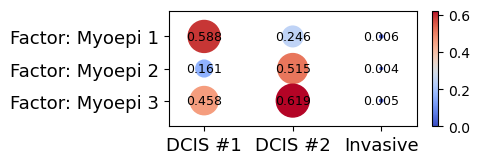

In [19]:
f, ax = plt.subplots(figsize=(4, 1.5))
n_topic = 3

for j in range(3):
    y = coloc_val[j, :]
    plt.scatter(np.arange(n_topic), (np.ones(n_topic)*(2-j)), c=y, s=y*900, cmap="coolwarm", vmin=0.0, vmax=0.62)
    y = ["%.3f" % y[t] for t in range(len(y))]
    for t in range(len(y)):
        plt.text(np.arange(n_topic)[t], (np.ones(n_topic)*(2-j))[t], [str(s) for s in list(y)][t], ha='center', va='center', fontsize=9)

plt.xticks(np.arange(3), ["DCIS #1", "DCIS #2", "Invasive"], rotation=0, fontsize=13)
plt.yticks(2-np.arange(3), ["Factor: Myoepi 1", "Factor: Myoepi 2", "Factor: Myoepi 3"], rotation=0, fontsize=13)
plt.ylim(-0.8, 2.8)
plt.xlim(-0.4, 2.4)
plt.colorbar()

plt.show()

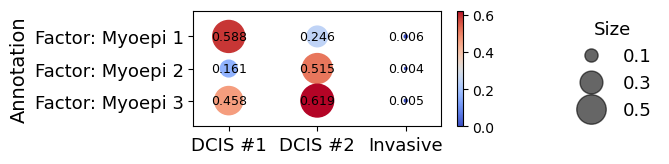

In [20]:
f, ax = plt.subplots(figsize=(4, 1.5))
n_topic = 3

for j in range(3):
    y = coloc_val[j, :]
    plt.scatter(np.arange(n_topic), (np.ones(n_topic)*(2-j)), c=y, s=y*900, cmap="coolwarm", vmin=0.0, vmax=0.62)
    y = ["%.3f" % y[t] for t in range(len(y))]
    for t in range(len(y)):
        plt.text(np.arange(n_topic)[t], (np.ones(n_topic)*(2-j))[t], [str(s) for s in list(y)][t], ha='center', va='center', fontsize=9)

plt.xticks(np.arange(3), ["DCIS #1", "DCIS #2", "Invasive"], rotation=0, fontsize=13)
plt.yticks(2-np.arange(3), ["Factor: Myoepi 1", "Factor: Myoepi 2", "Factor: Myoepi 3"], rotation=0, fontsize=13)
plt.ylim(-0.8, 2.8)
plt.xlim(-0.4, 2.4)
plt.colorbar()

scatter = plt.scatter([0, 0, 0], [0, 0, 0], c="white", alpha=0, s=np.array([0.1,0.3,0.5])*900)
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6)
legend2 = ax.legend(handles, ["0.1","0.3", "0.5"], title="Size", prop={"size": 13}, loc=(1.5, 0), frameon=False)
plt.ylabel("Annotation", fontsize=14)
plt.setp(legend2.get_title(),fontsize=13)

plt.show()